## **临床医学公开数据库作业**
                                翁浩然
                            2510108305
## 目录

* [0. 数据介绍](#0)
* [1. 数据读取](#1)
* [2. 数据预处理](#2)
* [3. 统计分析](#3)
* [4. 预测模型建立](#4)
* [5. 预测模型评估与可视化](#5)
* [6. 前端开发与部署](#6)

---
# 0. **数据介绍** <a class="anchor" id="0"></a>
---

相关数据链接：https://www.kaggle.com/datasets/oktayrdeki/heart-disease/data

这是一份在kaggle网站上拥有超20k下载的数据集，但最后的处理中我建立了失败的预测模型，所有模型的AUC值均接近0.5，所有特征相关系数均＜0.1，推测为在数据处理过程中的问题，或者本身该数据集正常人与患者身体指标差别不大导致无法有效建立预测模型。

数据简介：该数据集包含与心脏病相关的各种健康指标和风险因素。收集了年龄、性别、血压、胆固醇水平、吸烟习惯和锻炼模式等参数，用于分析心脏病风险并为健康研究提供数据支持。医疗专业人员、研究人员和数据分析师可以使用该数据集来研究与心脏病相关的趋势、识别风险因素，并进行各种健康相关分析。

列说明如下：

年龄：个人的年龄。

性别：个人的性别（男性或女性）。

血压：个人的血压（收缩压）。

胆固醇水平：个人的总胆固醇水平。

锻炼习惯：个人的锻炼习惯（低、中、高）。

吸烟：个人是否吸烟（是或否）。

家族心脏病：是否有家族心脏病史（是或否）。

糖尿病：个人是否患有糖尿病（是或否）。

BMI：个人的身体质量指数。

高血压：个人是否患有高血压（是或否）。

低HDL胆固醇：个人是否有低HDL胆固醇（是或否）。

高LDL胆固醇：个人是否有高LDL胆固醇（是或否）。

饮酒情况：个人的饮酒水平（无、低、中、高）。

压力水平：个人的压力水平（低、中、高）。

睡眠时长：个人的睡眠小时数。

糖摄入量：个人的糖摄入水平（低、中、高）。

甘油三酯水平：个人的甘油三酯水平。

空腹血糖：个人的空腹血糖水平。

CRP水平：C反应蛋白水平（炎症指标）。

同型半胱氨酸水平：个人的同型半胱氨酸水平（一种影响血管健康的氨基酸）。

心脏病状况：个人的心脏病状况（是或否）

---
# 1. **数据读取** <a class="anchor" id="1"></a>
---

In [1]:
# 载入所需package

from collections import Counter

import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.width', None)          
pd.set_option('display.expand_frame_repr', False)  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

In [2]:
# 读取数据
df = pd.read_csv(r'data\heart_disease.csv', keep_default_na=False, na_values=[''])
print(df.shape)
df.head()

(10000, 21)


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.00,Male,153.00,155.00,High,Yes,Yes,No,24.99,Yes,Yes,No,High,Medium,7.63,Medium,342.00,NaN,12.97,12.39,No
1,69.00,Female,146.00,286.00,High,No,Yes,Yes,25.22,No,Yes,No,Medium,High,8.74,Medium,133.00,157.00,9.36,19.30,No
2,46.00,Male,126.00,216.00,Low,No,No,No,29.86,No,Yes,Yes,Low,Low,4.44,Low,393.00,92.00,12.71,11.23,No
3,32.00,Female,122.00,293.00,High,Yes,Yes,No,24.13,Yes,No,Yes,Low,High,5.25,High,293.00,94.00,12.51,5.96,No
4,60.00,Male,166.00,242.00,Low,Yes,Yes,Yes,20.49,Yes,No,No,Low,High,7.03,High,263.00,154.00,10.38,8.15,No


---
# 2. **数据预处理** <a class="anchor" id="2"></a>
---

In [3]:
# 查看基本信息
df.info()
df.shape
df.describe()

# 检查缺失值
missing = df.isnull().sum()
missing[missing > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   9968 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

Age                     29
Gender                  19
Blood Pressure          19
Cholesterol Level       30
Exercise Habits         25
Smoking                 25
Family Heart Disease    21
Diabetes                30
BMI                     22
High Blood Pressure     26
Low HDL Cholesterol     25
High LDL Cholesterol    26
Alcohol Consumption     32
Stress Level            22
Sleep Hours             25
Sugar Consumption       30
Triglyceride Level      26
Fasting Blood Sugar     22
CRP Level               26
Homocysteine Level      20
dtype: int64

In [4]:
#接下来对数据类型进行分类，并处理缺失值

#数值类型：用中位数填充
num_cols = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 
            'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
            'CRP Level', 'Homocysteine Level']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

# 分类型列：用众数填充
cat_cols = ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes',
            'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
            'Alcohol Consumption', 'Stress Level', 'Heart Disease Status']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

In [5]:
#将分类变量转为数值
binary_cols = ['Gender', 'Smoking', 'Family Heart Disease', 'Diabetes',
               'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol']
for col in binary_cols:
    df[col] = df[col].map({'Male': 1, 'Female': 0, 'Yes': 1, 'No': 0})

# Exercise Habits: Low < Medium < High
exercise_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['Exercise Habits'] = df['Exercise Habits'].map(exercise_map)

# Alcohol Consumption: None < Low < Medium < High
alcohol_map = {'None': 0, 'Low': 1, 'Medium': 2, 'High': 3}
df['Alcohol Consumption'] = df['Alcohol Consumption'].map(alcohol_map)

# Stress Level: Low < Medium < High
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['Stress Level'] = df['Stress Level'].map(stress_map)

df['Heart Disease Status'] = df['Heart Disease Status'].map({'No': 0, 'Yes': 1})

---
# 3. **统计分析** <a class="anchor" id="3"></a>
---

为了探究不同指标与心脏病状态之间的关系，我们首先将样本按是否患有心脏病分为两组（健康组与患病组），然后分别对两组进行统计描述和假设检验。

**1. 连续型变量分析**
- 对年龄、血压、胆固醇、BMI、甘油三酯等连续变量，分别计算两组中的均值、中位数、标准差等统计量。
- 使用 Mann‑Whitney U 检验（非参数检验）比较两组在这些连续变量上的分布是否存在显著差异。该方法不要求数据服从正态分布，适用于大样本数据。

**2. 分类型变量分析**
- 对性别、吸烟、家族史、糖尿病、饮酒习惯等分类变量，采用卡方检验评估其与心脏病状态之间的独立性。
- 同时绘制堆叠柱状图，直观展示各分类变量在不同患病状态下的比例分布。

通过上述分析，可以初步筛选出与心脏病可能相关的风险因素，为后续建模提供参考。

In [6]:
# 首先按照患病状况分为两组
healthy = df[df['Heart Disease Status'] == 0]
disease = df[df['Heart Disease Status'] == 1]

In [7]:
continuous_vars = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 
                   'Sleep Hours',  'Triglyceride Level',
                   'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

df.groupby('Heart Disease Status')[continuous_vars].describe().T

Heart Disease Status            0       1
Age                 count 8000.00 2000.00
                    mean    49.38   48.96
                    std     18.19   18.07
                    min     18.00   18.00
                    25%     34.00   33.75
                    50%     49.00   49.00
                    75%     65.00   65.00
                    max     80.00   80.00
Blood Pressure      count 8000.00 2000.00
                    mean   149.88  149.27
                    std     17.58   17.46
                    min    120.00  120.00
                    25%    135.00  134.00
                    50%    150.00  149.00
                    75%    165.00  165.00
                    max    180.00  180.00
Cholesterol Level   count 8000.00 2000.00
                    mean   225.37  225.66
                    std     43.60   43.16
                    min    150.00  150.00
                    25%    187.00  188.00
                    50%    226.00  226.00
                    75%    263.00  263.00
                    max    300.00  300.00
BMI                 count 8000.00 2000.00
                    mean    29.02   29.33
                    std      6.30    6.28
                    min     18.00   18.01
                    25%     23.61   23.94
                    50%     29.01   29.47
                    75%     34.43   34.79
                    max     40.00   39.99
Sleep Hours         count 8000.00 2000.00
                    mean     6.99    6.98
                    std      1.75    1.76
                    min      4.00    4.00
                    25%      5.45    5.46
                    50%      7.00    6.97
                    75%      8.53    8.50
                    max     10.00   10.00
Triglyceride Level  count 8000.00 2000.00
                    mean   250.61  251.24
                    std     86.87   87.32
                    min    100.00  100.00
                    25%    176.00  177.00
                    50%    250.00  250.00
                    75%    325.00  328.00
                    max    400.00  400.00
Fasting Blood Sugar count 8000.00 2000.00
                    mean   120.17  120.04
                    std     23.59   23.42
                    min     80.00   80.00
                    25%     99.00  100.00
                    50%    120.00  120.00
                    75%    141.00  141.00
                    max    160.00  160.00
CRP Level           count 8000.00 2000.00
                    mean     7.49    7.42
                    std      4.34    4.30
                    min      0.00    0.01
                    25%      3.66    3.73
                    50%      7.50    7.34
                    75%     11.26   11.14
                    max     15.00   15.00
Homocysteine Level  count 8000.00 2000.00
                    mean    12.44   12.53
                    std      4.31    4.34
                    min      5.00    5.00
                    25%      8.71    8.85
                    50%     12.39   12.50
                    75%     16.10   16.28
                    max     20.00   20.00

In [8]:
def test_continuous_large(df, var, group_col='Heart Disease Status'):
    group0 = df[df[group_col]==0][var].dropna()
    group1 = df[df[group_col]==1][var].dropna()
    stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    mean0, mean1 = group0.mean(), group1.mean()
    median0, median1 = group0.median(), group1.median()
    return pd.Series({
        'Test': 'Mann-Whitney U',
        'Mean (healthy)': mean0,
        'Mean (disease)': mean1,
        'Median (healthy)': median0,
        'Median (disease)': median1,
        'Statistic': stat,
        'p-value': p
    })

# 应用到所有连续变量
continuous_vars = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 
                   'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 
                   'CRP Level', 'Homocysteine Level']
results = pd.DataFrame([test_continuous_large(df, var) for var in continuous_vars], 
                       index=continuous_vars)
results

,Test,Mean (healthy),Mean (disease),Median (healthy),Median (disease),Statistic,p-value
Age,Mann-Whitney U,49.38,48.96,49.00,49.00,8108894.50,0.35
Blood Pressure,Mann-Whitney U,149.88,149.27,150.00,149.00,8160435.00,0.16
Cholesterol Level,Mann-Whitney U,225.37,225.66,226.00,226.00,7968805.00,0.79
BMI,Mann-Whitney U,29.02,29.33,29.01,29.47,7773378.00,0.05
Sleep Hours,Mann-Whitney U,6.99,6.98,7.00,6.97,8044235.00,0.70
Triglyceride Level,Mann-Whitney U,250.61,251.24,250.00,250.00,7966037.00,0.77
Fasting Blood Sugar,Mann-Whitney U,120.17,120.04,120.00,120.00,8024912.50,0.83
CRP Level,Mann-Whitney U,7.49,7.42,7.50,7.34,8069716.00,0.55
Homocysteine Level,Mann-Whitney U,12.44,12.53,12.39,12.50,7903877.00,0.41


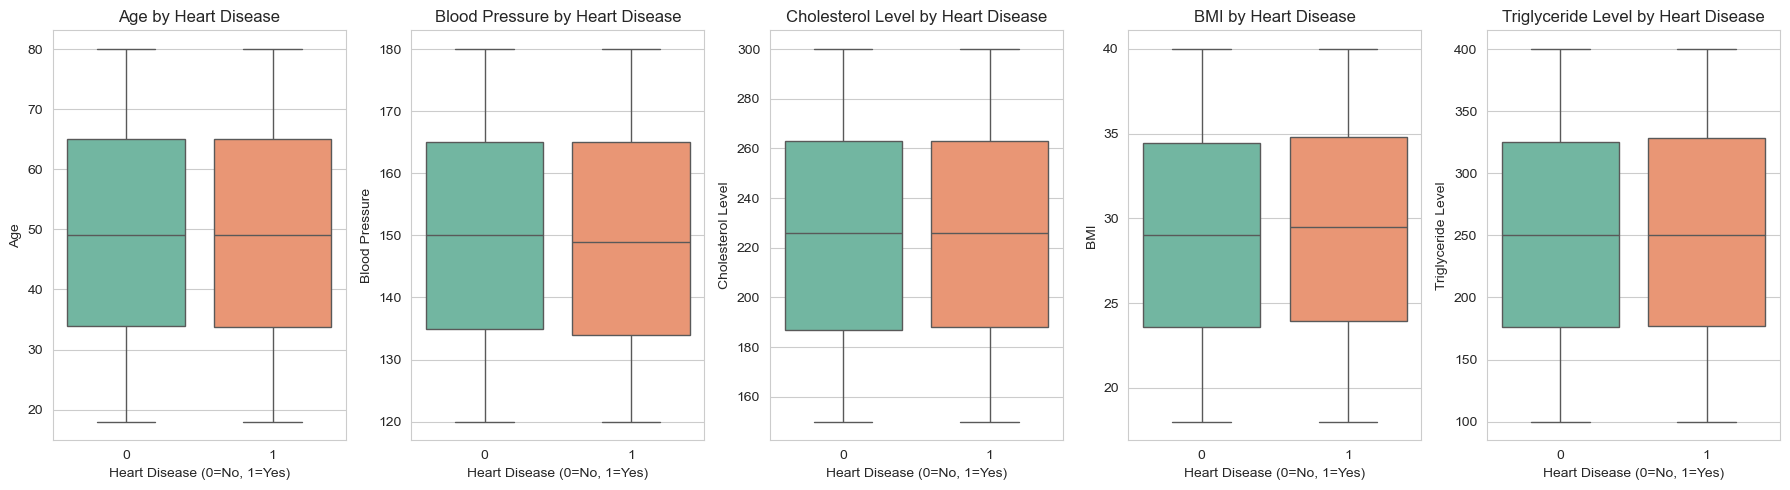

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.size'] = 10

important_cont = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Triglyceride Level']

fig, axes = plt.subplots(1, len(important_cont), figsize=(18, 5))
for ax, var in zip(axes, important_cont):
    sns.boxplot(x='Heart Disease Status', y=var, data=df, ax=ax,
                hue='Heart Disease Status', palette='Set2', legend=False)
    ax.set_title(f'{var} by Heart Disease')
    ax.set_xlabel('Heart Disease (0=No, 1=Yes)')
plt.tight_layout()
plt.show()

In [10]:
categorical_vars = ['Gender', 'Smoking', 'Family Heart Disease', 'Diabetes',
                    'Exercise Habits', 'Alcohol Consumption', 'Stress Level',
                    'High Blood Pressure', 'Low HDL Cholesterol','Sugar Consumption', 'High LDL Cholesterol']

参与分析的分类型变量： ['Gender', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Exercise Habits', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']
跳过 Sugar Consumption：交叉表形状 (2, 1)

=== 卡方检验结果（按p值升序）===
               Variable  Chi-square  p-value
9          Stress Level        7.46     0.02
0                Gender        2.87     0.09
8   Alcohol Consumption        3.21     0.36
6  High LDL Cholesterol        0.63     0.43
2  Family Heart Disease        0.53     0.47
5   Low HDL Cholesterol        0.33     0.57
7       Exercise Habits        0.48     0.79
1               Smoking        0.06     0.81
3              Diabetes        0.06     0.81
4   High Blood Pressure        0.04     0.85


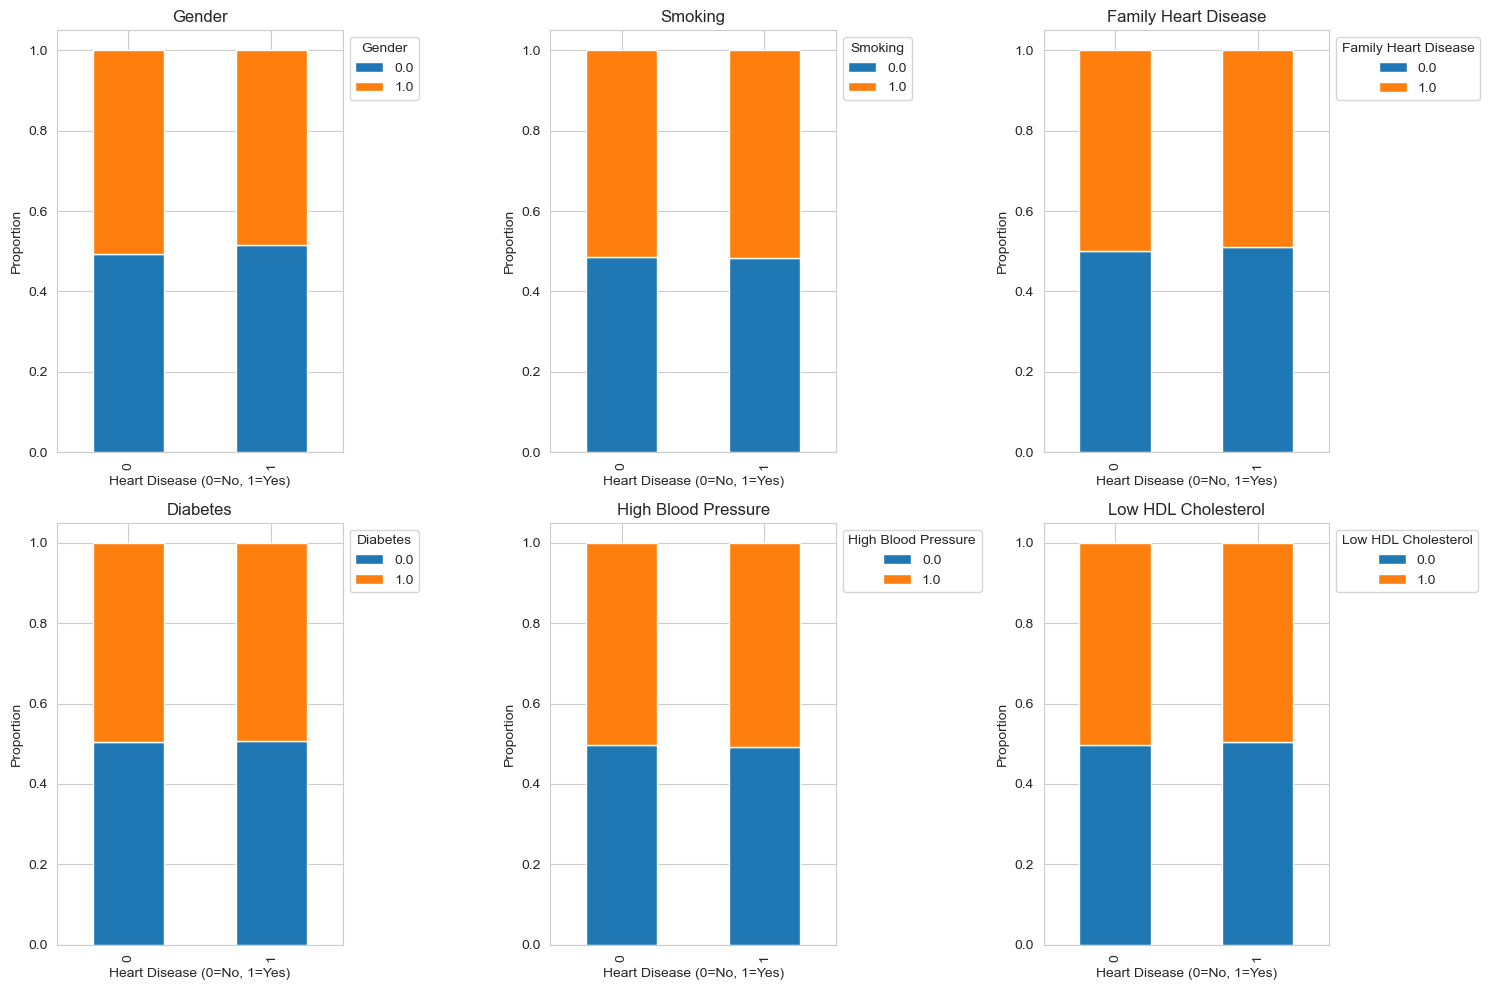

In [11]:
# 指定分类变量
categorical_vars = [
    'Gender', 'Smoking', 'Family Heart Disease', 'Diabetes',
    'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
    'Exercise Habits', 'Alcohol Consumption', 'Stress Level','Sugar Consumption'
]

# 保留数据中实际存在的列
categorical_vars = [var for var in categorical_vars if var in df.columns]

print("参与分析的分类型变量：", categorical_vars)

if not categorical_vars:
    print("没有找到分类变量，请检查列名是否正确。")
else:
    # 填充分类变量的缺失值（众数）
    for var in categorical_vars:
        if df[var].dtype == 'object':
            df[var] = df[var].astype('category')
        mode_val = df[var].mode()
        if not mode_val.empty:
            df[var] = df[var].fillna(mode_val.iloc[0])
        else:
            df[var] = df[var].fillna(0)   # 全缺失时的后备值

    # 卡方检验
    chi2_results = []
    for var in categorical_vars:
        valid = df[['Heart Disease Status', var]].dropna()
        if valid.empty:
            print(f"跳过 {var}：无有效数据")
            continue
        
        cross = pd.crosstab(valid['Heart Disease Status'], valid[var])
        if cross.shape[0] < 2 or cross.shape[1] < 2:
            print(f"跳过 {var}：交叉表形状 {cross.shape}")
            continue
        
        chi2, p, dof, expected = chi2_contingency(cross)
        
        prop_healthy = {}
        prop_disease = {}
        if 0 in cross.index:
            prop_healthy = (cross.loc[0] / cross.loc[0].sum()).to_dict()
        if 1 in cross.index:
            prop_disease = (cross.loc[1] / cross.loc[1].sum()).to_dict()
        
        chi2_results.append({
            'Variable': var,
            'Chi-square': chi2,
            'p-value': p,
            'Proportion_Healthy': prop_healthy,
            'Proportion_Disease': prop_disease
        })

    # 输出卡方检验结果表格
    if chi2_results:
        chi2_df = pd.DataFrame(chi2_results)[['Variable', 'Chi-square', 'p-value']]
        chi2_df = chi2_df.sort_values('p-value')
        print("\n=== 卡方检验结果（按p值升序）===")
        print(chi2_df)

        # 堆叠柱状图（最多显示前6个变量）
        n_plots = min(6, len(categorical_vars))
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        for idx, var in enumerate(categorical_vars[:n_plots]):
            pd.crosstab(df['Heart Disease Status'], df[var], normalize='index').plot(
                kind='bar', stacked=True, ax=axes[idx], legend=False)
            axes[idx].set_title(var)
            axes[idx].set_ylabel('Proportion')
            axes[idx].set_xlabel('Heart Disease (0=No, 1=Yes)')
            axes[idx].legend(title=var, bbox_to_anchor=(1, 1))
        for idx in range(n_plots, len(axes)):
            axes[idx].set_visible(False)
        plt.tight_layout()
        plt.show()
    else:
        print("没有成功完成任何卡方检验。")

---
# 4. **预测模型建立** <a class="anchor" id="4"></a>
---

### 预测模型建立

**1. 数据准备**
- 特征集 X 包含所有数值型和分类型变量（分类型变量已进行数值编码）。
- 目标变量 y 为“心脏病状态”（0 = 健康，1 = 患病）。
- 连续型特征经过标准化处理（StandardScaler），消除量纲影响。

**2. 模型选择**
- 采用 **随机森林**（Random Forest）作为主要模型，因为它能够自动捕捉非线性关系、处理特征交互，并给出特征重要性。
- 为应对类别不平衡（健康:患病 ≈ 4:1），在训练集上使用 **SMOTE** 过采样技术，使两类样本数量平衡。

**3. 训练与验证**
- 使用分层抽样（stratify=y）将数据划分为训练集（80%）和测试集（20%），确保两组中患病比例与原数据一致。
- 在平衡后的训练集上训练随机森林模型，参数设置为 `n_estimators=200`、`max_depth=15`。

**4. 模型输出**
- 模型可输出每个样本的患病概率（predict_proba）和二分类预测结果（predict）。

In [12]:
# 准备特征 X 和目标 y
continuous_vars = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 
                   'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 
                   'CRP Level', 'Homocysteine Level']

categorical_vars = ['Gender', 'Smoking', 'Family Heart Disease', 'Diabetes',
                    'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
                    'Exercise Habits', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']

from sklearn.preprocessing import StandardScaler

X = df[continuous_vars + categorical_vars].copy()
scaler = StandardScaler()
X[continuous_vars] = scaler.fit_transform(X[continuous_vars])
y = df['Heart Disease Status']

In [13]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 仅在训练集上应用 SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 训练随机森林
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
rf.fit(X_train_res, y_train_res)

# 预测与评估
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))
print("混淆矩阵:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1600
           1       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000

AUC-ROC: 0.4975828125
混淆矩阵:
 [[1599    1]
 [ 400    0]]


In [14]:
#检查特征编码和数据类型
print("特征数据类型:\n", X.dtypes.value_counts())
print("\n目标变量分布:\n", y.value_counts(normalize=True))

#检查特征与目标的均值差异
print("\n连续变量在健康/患病组的均值差异：")
for col in X.columns:
    if X[col].dtype in ['float64', 'int64']:
        mean0 = X[y==0][col].mean()
        mean1 = X[y==1][col].mean()
        diff = abs(mean1 - mean0)
        print(f"{col:25s}: 健康={mean0:.3f}, 患病={mean1:.3f}, 差异={diff:.3f}")

#检查随机森林在训练集上的表现
rf_train = RandomForestClassifier(n_estimators=100, random_state=42)
rf_train.fit(X_train, y_train)
train_pred = rf_train.predict(X_train)
print("\n随机森林在训练集上的分类报告（未用SMOTE）：")
print(classification_report(y_train, train_pred))

#尝试一个非常简单的逻辑回归，看AUC
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_proba_lr = lr.predict_proba(X_test)[:,1]
print("\n逻辑回归 AUC-ROC:", roc_auc_score(y_test, y_proba_lr))

特征数据类型:
 float64    20
Name: count, dtype: int64

目标变量分布:
 Heart Disease Status
0   0.80
1   0.20
Name: proportion, dtype: float64

连续变量在健康/患病组的均值差异：
Age                      : 健康=0.005, 患病=-0.018, 差异=0.023
Blood Pressure           : 健康=0.007, 患病=-0.028, 差异=0.035
Cholesterol Level        : 健康=-0.001, 患病=0.005, 差异=0.007
BMI                      : 健康=-0.010, 患病=0.039, 差异=0.049
Sleep Hours              : 健康=0.002, 患病=-0.008, 差异=0.010
Triglyceride Level       : 健康=-0.001, 患病=0.006, 差异=0.007
Fasting Blood Sugar      : 健康=0.001, 患病=-0.004, 差异=0.006
CRP Level                : 健康=0.003, 患病=-0.012, 差异=0.015
Homocysteine Level       : 健康=-0.004, 患病=0.017, 差异=0.021
Gender                   : 健康=0.506, 患病=0.485, 差异=0.021
Smoking                  : 健康=0.514, 患病=0.517, 差异=0.003
Family Heart Disease     : 健康=0.499, 患病=0.490, 差异=0.009
Diabetes                 : 健康=0.496, 患病=0.492, 差异=0.003
High Blood Pressure      : 健康=0.504, 患病=0.507, 差异=0.003
Low HDL Cholesterol      : 健康=0.504, 患病=0.496, 差异=0.008
H

In [15]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
# 检查特征与目标的相关性
correlations = X.corrwith(y).abs().sort_values(ascending=False)
print(correlations)

BMI                    0.02
Gender                 0.02
Blood Pressure         0.01
Alcohol Consumption    0.01
Stress Level           0.01
Age                    0.01
Homocysteine Level     0.01
High LDL Cholesterol   0.01
Family Heart Disease   0.01
CRP Level              0.01
Low HDL Cholesterol    0.01
Sleep Hours            0.00
Triglyceride Level     0.00
Cholesterol Level      0.00
Smoking                0.00
Diabetes               0.00
Fasting Blood Sugar    0.00
High Blood Pressure    0.00
Exercise Habits        0.00
Sugar Consumption       NaN
dtype: float64


---
# 5. **预测模型评估与可视化** <a class="anchor" id="5"></a>
---

### 预测模型评估与可视化

为了全面评估模型的性能，我们采用多个指标和图形进行诊断。

**1. 混淆矩阵（Confusion Matrix）**
- 以热力图形式展示模型在测试集上预测的正确与错误情况。
- 可以直观看出模型对健康类和患病类的分类准确度及误判类型（假阳性、假阴性）。

**2. ROC 曲线与 AUC**
- ROC 曲线展示了在不同分类阈值下，真正例率与假正例率之间的关系。
- AUC（曲线下面积）是综合衡量模型区分能力的指标，越接近 1 越好，0.5 表示随机猜测。

**3. 特征重要性（Feature Importance）**
- 随机森林可以输出每个特征在决策树分裂中的贡献度。
- 通过条形图显示重要性最高的前 15 个特征，帮助识别影响心脏病风险的关键因素。

**4. 模型比较**
- 在同一测试集上比较逻辑回归、随机森林和 XGBoost 三个模型的 AUC 值。
- 使用条形图直观对比各模型性能，便于选择最佳模型。

遗憾的是，所有模型的AUC值都接近0.5，推测为数据问题，故这里仅做方法演示。

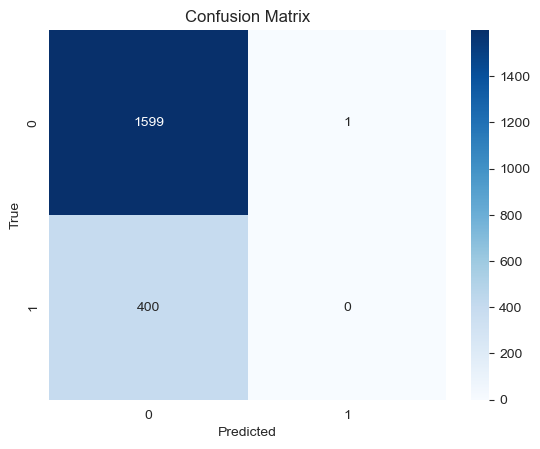

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

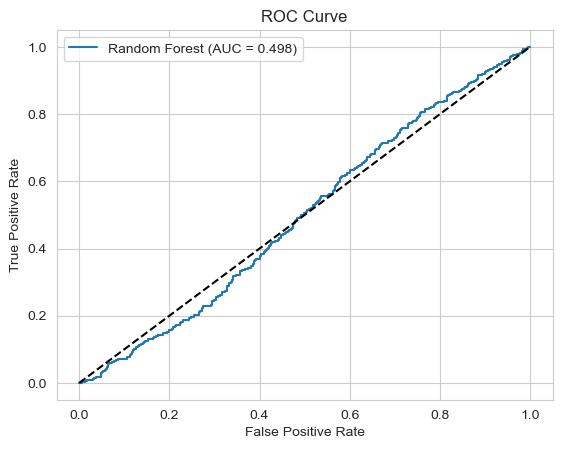

In [17]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

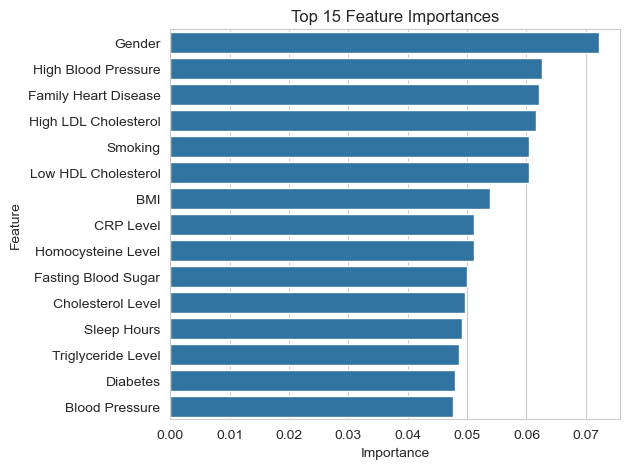

In [18]:
feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(15)
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

Logistic Regression AUC: 0.472
Random Forest AUC: 0.471
XGBoost AUC: 0.489


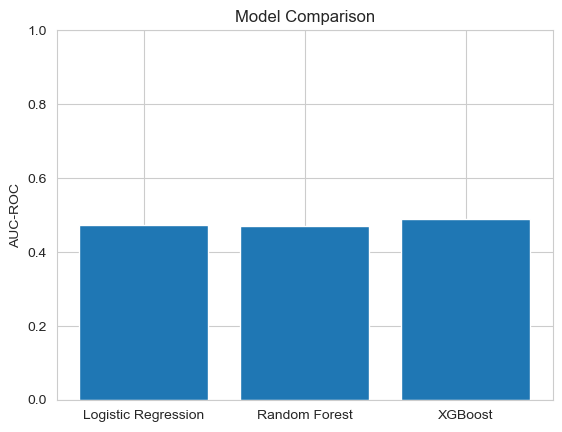

In [19]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier( eval_metric='logloss', random_state=42)
}

auc_scores = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_proba)
    auc_scores.append(auc)
    print(f'{name} AUC: {auc:.3f}')

plt.bar(models.keys(), auc_scores)
plt.ylabel('AUC-ROC')
plt.ylim(0, 1)
plt.title('Model Comparison')
plt.show()

---
# 6. **前端部署与开发** <a class="anchor" id="6"></a>
---

由于模型无法有效建立，故这一步的web网页也仅供参考，首先使用 `joblib` 将训练完毕的随机森林模型保存为 `heart_model.pkl` 文件，同时保存特征列表 `features.pkl`，确保前端提交的数据顺序与训练时一致，再搭建了简单的html页面实现交互，但预测结果可信度较低，仅供参考。

In [20]:
from flask import Flask, request, jsonify
import joblib
joblib.dump(rf, 'heart_model.pkl')
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'features.pkl')

print("模型已保存为 heart_model.pkl 和 features.pkl")

模型已保存为 heart_model.pkl 和 features.pkl


In [ ]:
from flask import Flask, request, jsonify
from flask_cors import CORS
import joblib
import numpy as np

app = Flask(__name__)
CORS(app)

model = joblib.load('heart_model.pkl')
feature_names = joblib.load('features.pkl')

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    input_values = [float(data.get(f, 0)) for f in feature_names]
    input_df = pd.DataFrame([input_values], columns=feature_names)
    prob = model.predict_proba(input_df)[0, 1]
    pred = int(prob >= 0.5)
    return jsonify({'probability': prob, 'prediction': pred})

app.run(debug=True, use_reloader=False, port=5000)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
